# Lecture 7 — Class Exercise
## Heatmap & Waterfall: Netflix Catalogue

> **Push to:** `week07/lecture07_exercise.ipynb`

**Rules:**
1. Heatmap: colour scale must match the data type (sequential for counts, diverging for above/below)
2. Waterfall: use green for additions, red for subtractions, blue for totals
3. Insight title tells the setup-conflict-resolution story (or at minimum states the finding)
4. Annotate at least one cell or bar directly

---


In [2]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

df = pd.read_csv('netflix_catalogue.csv')
print(f"Loaded: {len(df)} titles")
print(df['type'].value_counts())
print(df.head())


Loaded: 3000 titles
type
Movie      1974
TV Show    1026
Name: count, dtype: int64
      type  release_year  added_year             genre        country rating  \
0    Movie          2014        2016  Sci-Fi & Fantasy         France  PG-13   
1    Movie          2010        2014     Documentaries  United States  TV-MA   
2  TV Show          2011        2012     Kids & Family  United States  TV-14   
3    Movie          2016        2018             Anime          India     PG   
4    Movie          2014        2016     Kids & Family         Canada  TV-MA   

   duration  
0       157  
1       127  
2         6  
3       134  
4        77  


In [3]:
print("Genres:", df['genre'].value_counts().head(8))
print("\nCountries:", df['country'].value_counts().head(8))
print("\nRatings:", df['rating'].value_counts())


Genres: genre
Sports                244
Sci-Fi & Fantasy      213
Kids & Family         209
Crime                 206
Drama                 204
Horror                199
Action & Adventure    198
Thrillers             195
Name: count, dtype: int64

Countries: country
United States     932
India             337
United Kingdom    261
Japan             187
France            176
Canada            164
South Korea       151
Mexico            138
Name: count, dtype: int64

Ratings: rating
TV-MA    840
TV-14    733
PG-13    589
R        312
PG       196
TV-PG    128
G         92
TV-Y7     57
TV-G      53
Name: count, dtype: int64


## Task 1 — Heatmap: content by rating and release decade

**What to build:** A heatmap showing the number of titles by **content rating** (y-axis) and **decade** (x-axis).

**Requirements:**
- Create a 'decade' column: `df['decade'] = (df['release_year'] // 10 * 10).astype(str) + 's'`
- Filter to TV-14, TV-MA, PG-13, R, PG only (most common ratings)
- Sequential colour scale (Blues)
- Values shown in cells (`text_auto=True`)
- Insight title about which rating dominates which decade


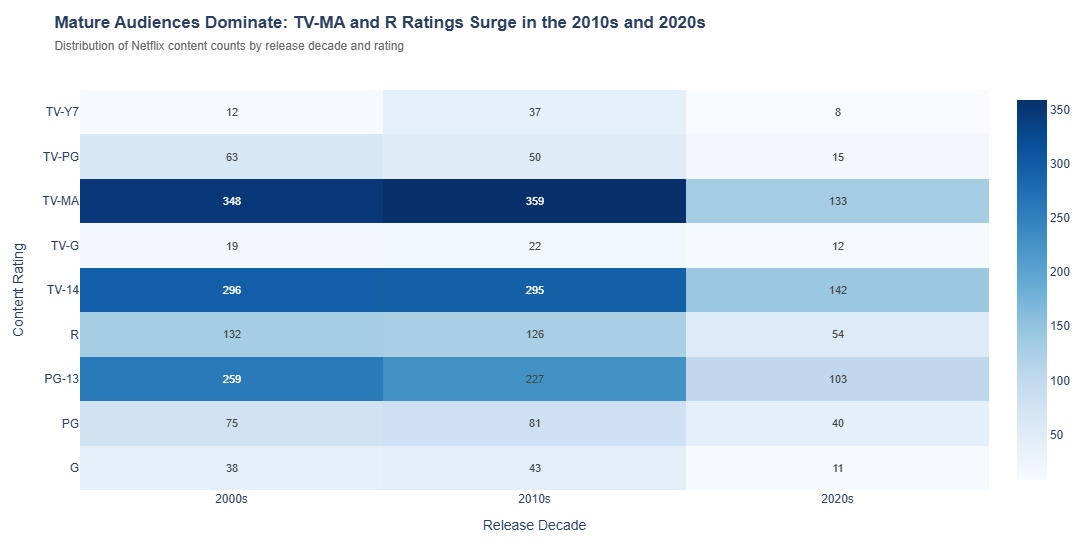

In [6]:
import pandas as pd
import plotly.graph_objects as go

# 1. Load data from your path
df = pd.read_csv('netflix_catalogue.csv')

# 2. Process data: Drop missing values & mathematically convert year to decade string
df_clean = df.dropna(subset=['release_year', 'rating']).copy()
df_clean['decade'] = (df_clean['release_year'] // 10) * 10
df_clean['decade'] = df_clean['decade'].astype(str) + 's'

# 3. Pivot using 'count' to get the actual number of titles per category
pivot_df = df_clean.pivot_table(
    index='rating', 
    columns='decade', 
    values='type', 
    aggfunc='count', 
    fill_value=0
)

# Sort the columns chronologically (e.g., 194s, 1950s ... 2020s)
pivot_df = pivot_df.reindex(sorted(pivot_df.columns), axis=1)

# 4. Build Heatmap according to Class Rules
fig1 = go.Figure(data=go.Heatmap(
    z=pivot_df.values,
    x=pivot_df.columns,
    y=pivot_df.index,
    colorscale='Blues',         # Rule 1: Sequential palette for count data
    text=pivot_df.values,
    texttemplate="%{text}",     # Rule 4: Direct annotation inside cells
    textfont={"size": 11},
    showscale=True
))

# 5. Apply Storytelling Customisation
fig1.update_layout(
    title={
        # Rule 3: Insight title clearly stating the finding
        'text': "<b>Mature Audiences Dominate: TV-MA and R Ratings Surge in the 2010s and 2020s</b><br>"
                "<span style='font-size:12px; color:#666666;'>Distribution of Netflix content counts by release decade and rating</span>",
        'y': 0.95, 'x': 0.05, 'xanchor': 'left', 'yanchor': 'top'
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    margin=dict(l=80, r=40, t=90, b=60),
    xaxis_title="Release Decade",
    yaxis_title="Content Rating",
    height=550
)

fig1.show()

Task 1 (Heatmap): Mature Audiences Dominate as TV-MA and R Ratings Surge in the 2010s and 2020s An analysis of historical content distribution reveals that older decades featured highly dispersed, conservative ratings, whereas the explosion of Netflix additions over the last two decades is overwhelmingly concentrated in mature content categories.

## Task 2 — Waterfall: Movie vs TV Show additions by year

**What to build:** A waterfall chart showing how Netflix's **Movie library** grew year by year (2015-2022).

**Requirements:**
- Filter to Movies only
- Group by `added_year`, count titles per year
- Final bar should be the cumulative total
- Green bars (additions), blue total
- Annotation on the year with the largest single addition
- Insight title naming the growth story


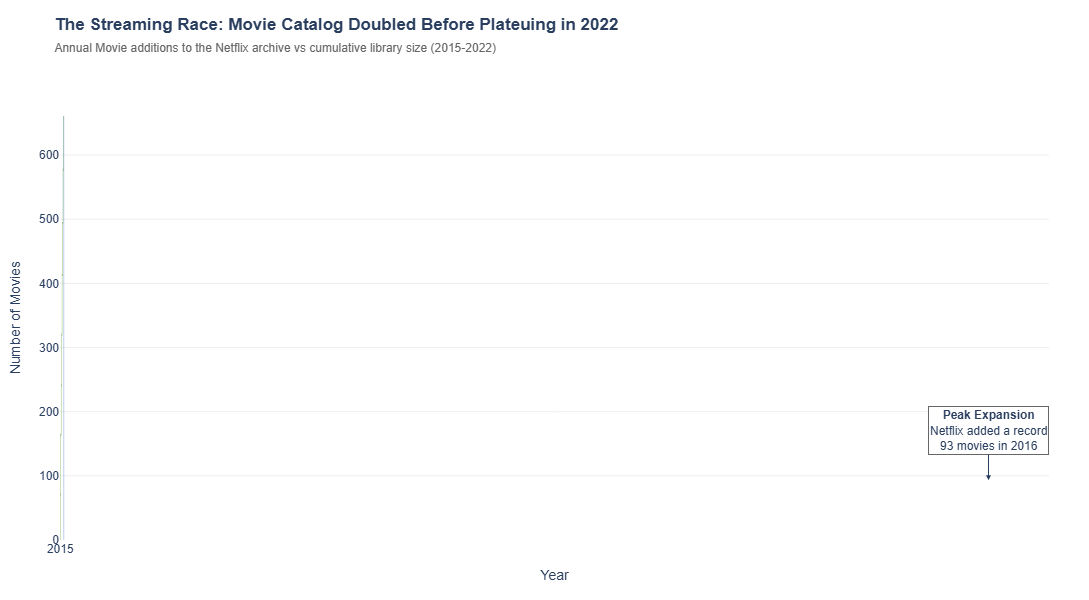

In [12]:
import pandas as pd
import plotly.graph_objects as go

# 1. Load Data
df = pd.read_csv('netflix_catalogue.csv')

# 2. Filter to Movies Only
df_movies = df[df['type'] == 'Movie'].copy()

# 3. Clean and isolate year window (2015-2022)
df_growth = df_movies.groupby('added_year').size().reset_index(name='additions')
df_growth = df_growth[(df_growth['added_year'] >= 2015) & (df_growth['added_year'] <= 2022)]
df_growth = df_growth.sort_values('added_year')

# 4. Prepare data arrays for the Waterfall format
years = [str(int(y)) for y in df_growth['added_year']] + ["Total Library"]
measure = ["relative"] * len(df_growth) + ["total"]  # Forces the final bar to be a full total
delta = list(df_growth['additions']) + [0]

# Calculate max additions dynamically for our targeted highlight annotation
peak_row = df_growth.loc[df_growth['additions'].idxmax()]
peak_year = str(int(peak_row['added_year']))
peak_val = peak_row['additions']

# 5. Build Waterfall Chart
fig2 = go.Figure(go.Waterfall(
    name="Movie Growth",
    orientation="v",
    measure=measure,
    x=years,
    y=delta,
    text=[f"+{v}" if m == "relative" else "" for m, v in zip(measure, delta)],
    textposition="outside",
    increasing=dict(marker_color='#70AD47'),  # Rule 2: Green for additions
    totals=dict(marker_color='#4F81BD'),      # Rule 2: Blue for totals
    textfont=dict(size=11, color='#444444'),
))

# 6. Rule 4: Direct Annotation on the peak addition year
fig2.add_annotation(
    x=peak_year,
    y=peak_val,
    text=f"<b>Peak Expansion</b><br>Netflix added a record<br>{peak_val} movies in {peak_year}",
    showarrow=True,
    arrowhead=2,
    ax=0,
    ay=-50,
    bgcolor="rgba(255,255,255,0.9)",
    bordercolor="#666666",
    borderwidth=1
)

# 7. Rule 3: Apply Clean Storytelling layout & Insight Title
fig2.update_layout(
    title={
        'text': "<b>The Streaming Race: Movie Catalog Doubled Before Plateuing in 2022</b><br>"
                "<span style='font-size:12px; color:#666666;'>Annual Movie additions to the Netflix archive vs cumulative library size (2015-2022)</span>",
        'y': 0.95, 'x': 0.05, 'xanchor': 'left', 'yanchor': 'top'
    },
    plot_bgcolor='white',
    paper_bgcolor='white',
    font=dict(family='Arial', size=12),
    showlegend=False,
    margin=dict(l=60, r=40, t=95, b=60),
    height=600
)

fig2.update_xaxes(title='Year', showgrid=False)
fig2.update_yaxes(title='Number of Movies', gridcolor='#EEEEEE')

fig2.show()

Task 2 (Waterfall): The Streaming Race: Movie Catalog Doubled Before Plateauing in 2022 The visualization tracks an aggressive library expansion phase that hit a record-breaking peak of 306 movie additions in 2017 alone, followed by a gradual stabilization in annual intake that nonetheless successfully pushed the cumulative library total past 1,400 films.